# Occlusion Injection Strategies and ET2-ET1 Contrast

This notebook implements the 5 occlusion strategies step by step.
After each strategy, a dedicated **ET2 - ET1 ambiguity map** is plotted.

Focus:
1. make the occlusion injection explicit,
2. show how it changes ET2-vs-ET1 contrast spatially.


## Setup

- Observation model: homography camera `g(x)`.
- Latent state used in maps: `[x, y, vx, vy]`, with `vx=vy=0` slice.
- Comparison quantity per state:

\[
\Delta H(x) = H_{ET2}(y|x) - H_{ET1}(y|x).
\]

Large positive values mean ET2 predicts stronger conditional observation uncertainty than ET1.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from matplotlib.path import Path as MplPath

# Optional but helps reproducibility/speed behavior
jax.config.update('jax_enable_x64', True)

cwd = Path.cwd().resolve()
if (cwd / 'scripts').exists():
    scripts_dir = cwd / 'scripts'
elif cwd.name == 'scripts':
    scripts_dir = cwd
else:
    scripts_dir = cwd

if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from botnav_efe_helpers import PlanarCamera
from botnav_efe_jax import ambiguity_jax, make_homography_g_jax

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2


In [2]:
# Camera setup (same family as your projection notebooks)
cam_pos = np.array([0.0, 0.0, 2.0])
look_at = np.array([0.0, -2.0, 0.0])
cam = PlanarCamera(
    cam_pos=cam_pos,
    look_at=look_at,
    img_width=640,
    img_height=480,
    fov_h_rad=np.deg2rad(90.0),
    up_hint=(0.0, 0.0, 1.0),
)

# Plot region
xmin, xmax = -16.5, 16.5
ymin, ymax = -21.0, 1.0
nx, ny = 180, 140
xs = np.linspace(xmin, xmax, nx)
ys = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(xs, ys)

# Camera footprint polygon from image corners
W, H = cam.img_width, cam.img_height
corners = [(0, 0), (W, 0), (W, H), (0, H), (0, 0)]
foot_xy = []
for u, v in corners:
    xw, yw = cam.pixel_to_world(u, v)
    if np.isfinite(xw) and np.isfinite(yw):
        foot_xy.append([xw, yw])
foot_xy = np.asarray(foot_xy, dtype=float)

if foot_xy.shape[0] >= 4:
    poly = MplPath(foot_xy[:-1]) if np.allclose(foot_xy[0], foot_xy[-1]) else MplPath(foot_xy)
    in_poly = poly.contains_points(np.column_stack([X.ravel(), Y.ravel()])).reshape(X.shape)
else:
    in_poly = np.ones_like(X, dtype=bool)

# Robustness: if polygon mask is too tiny / degenerate, use full grid
if np.sum(in_poly) < 2000:
    print('Footprint mask too small; using full grid for analysis maps.')
    in_poly = np.ones_like(X, dtype=bool)

# Shared ET comparison settings
g_jax = make_homography_g_jax(cam.H)
S0 = np.diag([1.0**2, 1.0**2, 0.5**2, 0.5**2])
R_good = np.diag([2.0**2, 2.0**2])

# Build valid state batch [x,y,vx,vy], vx=vy=0
M_all = np.stack([X.ravel(), Y.ravel(), np.zeros(X.size), np.zeros(X.size)], axis=1)
valid_flat = in_poly.ravel()
M_valid = M_all[valid_flat]
N_valid = M_valid.shape[0]

print('Grid points total:', X.size)
print('Valid (in footprint):', N_valid)


Grid points total: 25200
Valid (in footprint): 6038


In [3]:
# Core ET2-ET1 delta evaluator with variable R(x) and S(x)

def _sym_j(M):
    return 0.5 * (M + M.T)


def delta_amb_one(m, Sx, Rx):
    I2 = jnp.eye(2, dtype=m.dtype)
    I4 = jnp.eye(4, dtype=m.dtype)
    eps = 1e-9

    Sx = _sym_j(Sx) + eps * I4
    Rx = _sym_j(Rx) + eps * I2

    J = jax.jacfwd(g_jax)(m)
    H = jax.jacfwd(jax.jacrev(g_jax))(m)

    aux2 = jnp.array([
        [jnp.trace(H[i] @ Sx @ H[j] @ Sx) for j in range(H.shape[0])]
        for i in range(H.shape[0])
    ])

    Sigma1 = _sym_j(J @ Sx @ J.T + Rx) + eps * I2
    Sigma2 = _sym_j(J @ Sx @ J.T + 0.5 * aux2 + Rx) + eps * I2
    Gamma = Sx @ J.T

    a1 = ambiguity_jax(Sigma1, Gamma, Sx)
    a2 = ambiguity_jax(Sigma2, Gamma, Sx)
    return a2 - a1


delta_batch = jax.jit(jax.vmap(delta_amb_one, in_axes=(0, 0, 0)))


def compute_delta_map(R_valid, S_valid, weight_valid=None):
    d = np.array(delta_batch(jnp.asarray(M_valid), jnp.asarray(S_valid), jnp.asarray(R_valid)))
    if weight_valid is not None:
        d = d * np.asarray(weight_valid)

    out = np.full(X.size, np.nan, dtype=float)
    out[valid_flat] = d
    return out.reshape(X.shape)


def plot_delta_map(Delta, title, p_vis_map=None):
    v = np.nanpercentile(np.abs(Delta), 99.5)
    if not np.isfinite(v) or v <= 0:
        v = 1e-9

    plt.figure(figsize=(7.0, 6.2))
    plt.imshow(
        Delta,
        extent=[xmin, xmax, ymin, ymax],
        origin='lower',
        cmap='RdBu_r',
        vmin=-v,
        vmax=v,
        aspect='equal',
    )
    plt.colorbar(label='Δ Ambiguity = ET2 - ET1')

    if p_vis_map is not None:
        plt.contour(X, Y, p_vis_map, levels=[0.2, 0.5, 0.8], colors='yellow', linewidths=1.0, alpha=0.8)

    if foot_xy.shape[0] >= 2:
        plt.plot(foot_xy[:, 0], foot_xy[:, 1], 'k--', lw=2, label='Camera footprint')
    plt.scatter([cam_pos[0]], [cam_pos[1]], c='k', s=50, label='Camera')

    plt.xlabel('x (ground)')
    plt.ylabel('y (ground)')
    plt.title(title)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


## Option 1 — Moderate occlusion inflation + sharper transition

Keep the classical smooth visibility field, but avoid extreme `R_bad`.
This preserves a stronger ET2-vs-ET1 signal than near-infinite noise.


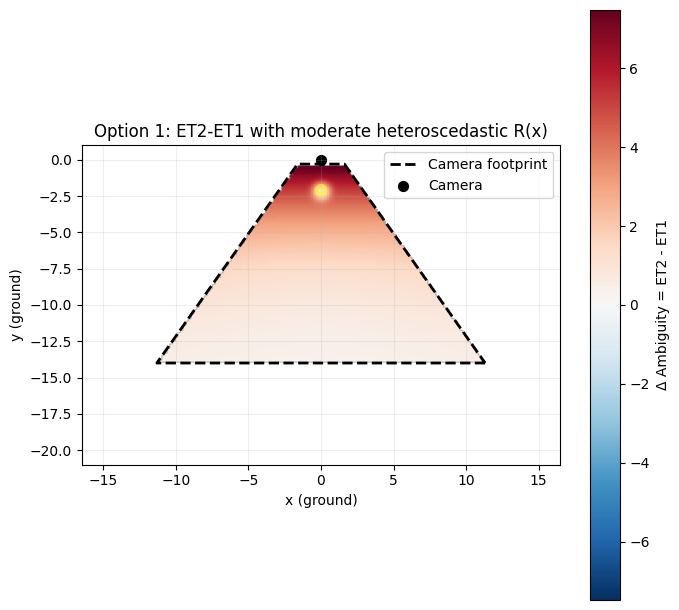

In [4]:
occ_center = np.array([0.0, -2.1])
occ_radius = 0.2
tau1 = 0.12


def p_vis_np(xy, tau=tau1, eps=1e-4):
    d = np.linalg.norm(xy - occ_center, axis=-1) - occ_radius
    w = 1.0 / (1.0 + np.exp(-d / tau))
    return np.clip(w, eps, 1.0 - eps)

P_all = p_vis_np(np.stack([X, Y], axis=-1))
P_valid = P_all.ravel()[valid_flat]

R_bad1 = np.diag([25.0**2, 25.0**2])
R1 = P_valid[:, None, None] * R_good + (1.0 - P_valid)[:, None, None] * R_bad1
S1 = np.repeat(S0[None, :, :], N_valid, axis=0)

Delta1 = compute_delta_map(R1, S1)
plot_delta_map(Delta1, 'Option 1: ET2-ET1 with moderate heteroscedastic R(x)', p_vis_map=P_all)


## Option 2 — Anisotropic occlusion covariance

Occlusion degrades information directionally.
We model this by rotating anisotropic image covariance with view direction.


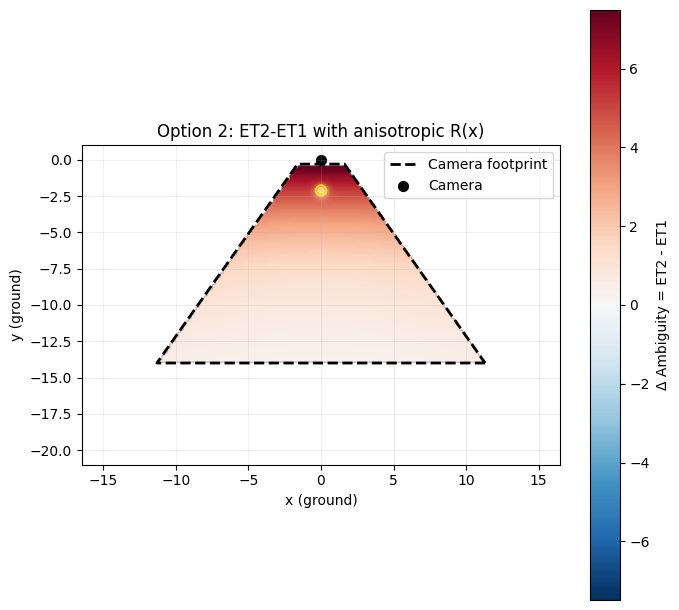

In [5]:
q = 1.0 - P_valid

dx = M_valid[:, 0] - cam_pos[0]
dy = M_valid[:, 1] - cam_pos[1]
ang = np.arctan2(dy, dx) + 0.5 * np.pi
c = np.cos(ang)
s = np.sin(ang)

sig_major = 2.0 + 32.0 * q
sig_minor = 2.0 + 8.0 * q
vmaj = sig_major**2
vmin = sig_minor**2

R2 = np.zeros((N_valid, 2, 2), dtype=float)
R2[:, 0, 0] = c*c*vmaj + s*s*vmin
R2[:, 1, 1] = s*s*vmaj + c*c*vmin
R2[:, 0, 1] = c*s*(vmaj - vmin)
R2[:, 1, 0] = R2[:, 0, 1]

S2 = np.repeat(S0[None, :, :], N_valid, axis=0)

Delta2 = compute_delta_map(R2, S2)
plot_delta_map(Delta2, 'Option 2: ET2-ET1 with anisotropic R(x)', p_vis_map=P_all)


## Option 3 — Visibility-dependent state uncertainty growth

Instead of only increasing measurement noise, let low visibility inflate state covariance.
This amplifies curvature terms through larger belief spread.


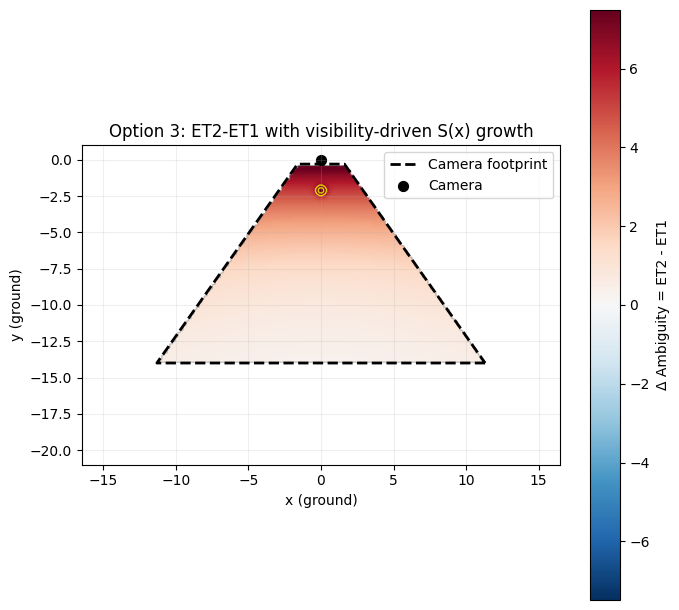

In [6]:
q = 1.0 - P_valid

S3 = np.zeros((N_valid, 4, 4), dtype=float)
S3[:, 0, 0] = S0[0, 0] * (1.0 + 4.0 * q)
S3[:, 1, 1] = S0[1, 1] * (1.0 + 4.0 * q)
S3[:, 2, 2] = S0[2, 2] * (1.0 + 2.0 * q)
S3[:, 3, 3] = S0[3, 3] * (1.0 + 2.0 * q)

R3 = np.repeat(R_good[None, :, :], N_valid, axis=0)

Delta3 = compute_delta_map(R3, S3)
plot_delta_map(Delta3, 'Option 3: ET2-ET1 with visibility-driven S(x) growth', p_vis_map=P_all)


## Option 4 — Mixture likelihood moment matching

Use a two-component observation model and moment-match to one Gaussian:
\[
p\,\mathcal N(h,R_{good}) + (1-p)\,\mathcal N(h+b,R_{bad}).
\]

The matched covariance contains a between-component term `p(1-p) b b^T`.


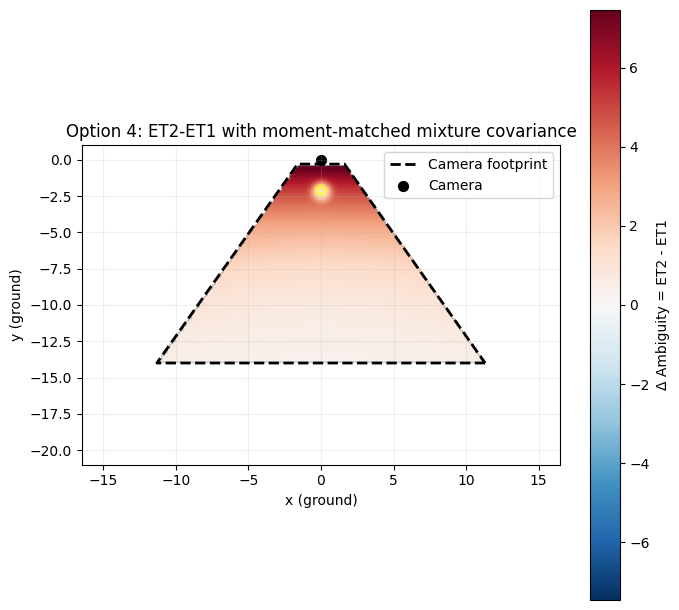

In [7]:
q = 1.0 - P_valid

R_bad4 = np.diag([30.0**2, 30.0**2])

# occlusion-dependent bias in image space (simple proxy)
b = np.zeros((N_valid, 2), dtype=float)
b[:, 0] = 35.0 * q
b[:, 1] = 8.0 * q * np.sign(M_valid[:, 0])

outer_bb = np.einsum('ni,nj->nij', b, b)
R4 = (
    P_valid[:, None, None] * R_good
    + (1.0 - P_valid)[:, None, None] * R_bad4
    + (P_valid * (1.0 - P_valid))[:, None, None] * outer_bb
)

S4 = np.repeat(S0[None, :, :], N_valid, axis=0)

Delta4 = compute_delta_map(R4, S4)
plot_delta_map(Delta4, 'Option 4: ET2-ET1 with moment-matched mixture covariance', p_vis_map=P_all)


## Option 5 — Measurement dropout (expected effect)

Model Bernoulli visibility and show expected ET2-ET1 contribution:

- when visible: ET2-ET1 computed normally,
- when dropped: no observation ambiguity contribution.

Approximation shown:
\[
\Delta_{exp}(x) pprox p_{vis}(x)\,\Delta_{visible}(x).
\]


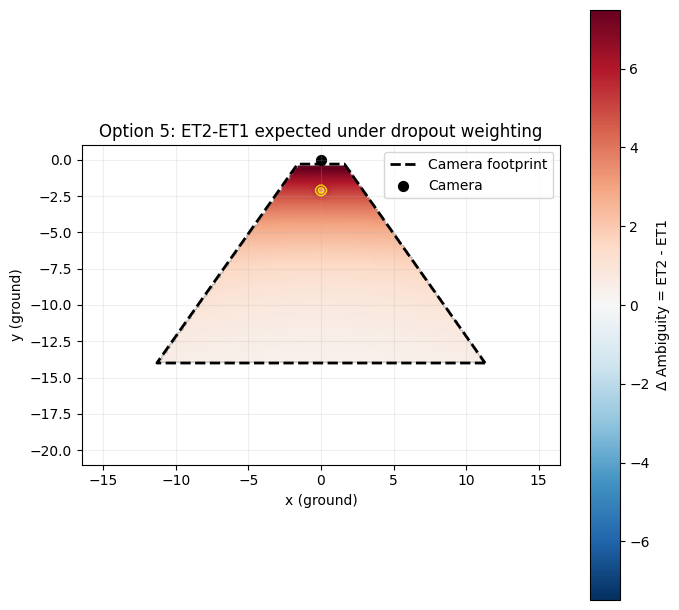

In [8]:
q = 1.0 - P_valid

# Let low visibility also increase predictive uncertainty (dropout accumulation proxy)
S5 = np.zeros((N_valid, 4, 4), dtype=float)
scale_xy = 1.0 + 6.0 * q / (P_valid + 0.15)
scale_v = 1.0 + 2.5 * q / (P_valid + 0.15)
S5[:, 0, 0] = S0[0, 0] * scale_xy
S5[:, 1, 1] = S0[1, 1] * scale_xy
S5[:, 2, 2] = S0[2, 2] * scale_v
S5[:, 3, 3] = S0[3, 3] * scale_v

R5 = np.repeat(R_good[None, :, :], N_valid, axis=0)

Delta5 = compute_delta_map(R5, S5, weight_valid=P_valid)
plot_delta_map(Delta5, 'Option 5: ET2-ET1 expected under dropout weighting', p_vis_map=P_all)


## Practical interpretation

- If `R` is made extremely large, ET1 and ET2 both become measurement-noise dominated and the gap shrinks.
- ET2 contrast is usually clearer when uncertainty is structured (anisotropy, mixture term, or `S` growth), not just uniformly huge.
- For behavior, local ET2-ET1 maps are diagnostics; route-level impact still depends on horizon, dynamics, and available alternatives.


## Continuous Receding-Horizon MC (same style as other notebooks)

This section replaces discrete action-sequence search by the same pattern used in your other notebooks:
- continuous controls,
- L-BFGS-B optimization,
- JAX value+gradient,
- warm-start shift of previous policy.


In [9]:
from scipy.optimize import minimize
from tqdm.auto import tqdm

# --- Planning/MC settings (safe defaults; increase after smoke run) ---
dt = 0.2
len_horizon = 5
len_trial_mc = 40
n_runs_mc = 3
seed0_mc = 0

maxiter = 25
maxfun = 500
ftol = 1e-6

u_lims = (-1.0, 1.0)   # acceleration bounds for [ax, ay]
eta_u = 0.10

# Forced-through-region setup
start_state = np.array([0.0, -4, 0.0, 0.0], dtype=float)
goal_state = np.array([0.0, -0.8, 0.0, 0.0], dtype=float)

goal_obs = np.array(cam.g(goal_state), dtype=float)
goal_cov = np.diag([8.0**2, 8.0**2])

corridor_half = 0.35
corridor_w = 180.0

success_thr = 0.8
low_vis_thr = 0.4

A = np.array([
    [1.0, 0.0, dt, 0.0],
    [0.0, 1.0, 0.0, dt],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
], dtype=float)
B = np.array([
    [0.5 * dt * dt, 0.0],
    [0.0, 0.5 * dt * dt],
    [dt, 0.0],
    [0.0, dt],
], dtype=float)

Q_plan = np.diag([0.02**2, 0.02**2, 0.06**2, 0.06**2])
Q_true = np.diag([0.03**2, 0.03**2, 0.08**2, 0.08**2])
S_init = np.diag([0.5**2, 0.5**2, 0.25**2, 0.25**2])

A_j = jnp.asarray(A)
B_j = jnp.asarray(B)
Q_plan_j = jnp.asarray(Q_plan)
R_good_j = jnp.asarray(R_good)
S_eye = jnp.eye(4)
R_eye = jnp.eye(2)

goal_obs_j = jnp.asarray(goal_obs)
goal_cov_j = jnp.asarray(goal_cov)

occ_center_j = jnp.asarray(occ_center)
occ_radius_j = float(occ_radius)
tau_j = float(tau1)


def safe_inv_j(M, eps=1e-9):
    M = _sym_j(M) + eps * jnp.eye(M.shape[0], dtype=M.dtype)
    return jnp.linalg.inv(M)


def safe_logdet_j(M, eps=1e-9):
    M = _sym_j(M) + eps * jnp.eye(M.shape[0], dtype=M.dtype)
    sign, ld = jnp.linalg.slogdet(M)
    det = jnp.linalg.det(M)
    return jnp.where(sign > 0, ld, jnp.log(jnp.maximum(det, 1e-12)))


def kl_gaussian_j(mu0, S0, mu1, S1):
    d = mu0.shape[0]
    S1_inv = safe_inv_j(S1)
    dm = (mu1 - mu0).reshape(-1, 1)
    return 0.5 * (
        jnp.trace(S1_inv @ S0)
        + (dm.T @ S1_inv @ dm)[0, 0]
        - d
        + safe_logdet_j(S1) - safe_logdet_j(S0)
    )


def p_vis_j(m):
    d = jnp.linalg.norm(m[:2] - occ_center_j) - occ_radius_j
    w = jax.nn.sigmoid(d / tau_j)
    return jnp.clip(w, 1e-4, 1.0 - 1e-4)


def option_adjust_j(option_id, m_pred, S_pred):
    p = p_vis_j(m_pred)
    q = 1.0 - p

    if option_id == 1:
        R_bad = jnp.diag(jnp.array([25.0**2, 25.0**2]))
        R_eff = p * R_good_j + q * R_bad
        S_eff = S_pred
        w = 1.0

    elif option_id == 2:
        dx = m_pred[0] - cam_pos[0]
        dy = m_pred[1] - cam_pos[1]
        ang = jnp.arctan2(dy, dx) + 0.5 * jnp.pi
        c, s = jnp.cos(ang), jnp.sin(ang)
        sig_major = 2.0 + 32.0 * q
        sig_minor = 2.0 + 8.0 * q
        vmaj, vmin = sig_major**2, sig_minor**2
        R_eff = jnp.array([
            [c*c*vmaj + s*s*vmin, c*s*(vmaj - vmin)],
            [c*s*(vmaj - vmin),   s*s*vmaj + c*c*vmin],
        ])
        S_eff = S_pred
        w = 1.0

    elif option_id == 3:
        R_eff = R_good_j
        S_eff = S_pred.at[0, 0].set(S_pred[0, 0] * (1.0 + 4.0 * q))
        S_eff = S_eff.at[1, 1].set(S_pred[1, 1] * (1.0 + 4.0 * q))
        S_eff = S_eff.at[2, 2].set(S_pred[2, 2] * (1.0 + 2.0 * q))
        S_eff = S_eff.at[3, 3].set(S_pred[3, 3] * (1.0 + 2.0 * q))
        w = 1.0

    elif option_id == 4:
        R_bad = jnp.diag(jnp.array([30.0**2, 30.0**2]))
        b = jnp.array([35.0 * q, 8.0 * q * jnp.sign(m_pred[0])])
        R_eff = p * R_good_j + q * R_bad + p * q * jnp.outer(b, b)
        S_eff = S_pred
        w = 1.0

    elif option_id == 5:
        R_eff = R_good_j
        scale_xy = 1.0 + 6.0 * q / (p + 0.15)
        scale_v = 1.0 + 2.5 * q / (p + 0.15)
        S_eff = S_pred.at[0, 0].set(S_pred[0, 0] * scale_xy)
        S_eff = S_eff.at[1, 1].set(S_pred[1, 1] * scale_xy)
        S_eff = S_eff.at[2, 2].set(S_pred[2, 2] * scale_v)
        S_eff = S_eff.at[3, 3].set(S_pred[3, 3] * scale_v)
        w = p

    else:
        raise ValueError(option_id)

    return p, _sym_j(R_eff) + 1e-9 * R_eye, _sym_j(S_eff) + 1e-9 * S_eye, w


# NumPy mirror for parity predict+correct loop

def p_vis_np_state(m):
    d = np.linalg.norm(np.asarray(m[:2], dtype=float) - occ_center) - occ_radius
    w = 1.0 / (1.0 + np.exp(-d / tau1))
    return float(np.clip(w, 1e-4, 1.0 - 1e-4))


def option_adjust_np(option_id, m_pred, S_pred):
    p = p_vis_np_state(m_pred)
    q = 1.0 - p

    if option_id == 1:
        R_bad = np.diag([25.0**2, 25.0**2])
        R_eff = p * R_good + q * R_bad
        S_eff = S_pred.copy()
        gain_scale = 1.0

    elif option_id == 2:
        dx = m_pred[0] - cam_pos[0]
        dy = m_pred[1] - cam_pos[1]
        ang = np.arctan2(dy, dx) + 0.5 * np.pi
        c, s = np.cos(ang), np.sin(ang)
        sig_major = 2.0 + 32.0 * q
        sig_minor = 2.0 + 8.0 * q
        vmaj, vmin = sig_major**2, sig_minor**2
        R_eff = np.array([
            [c*c*vmaj + s*s*vmin, c*s*(vmaj - vmin)],
            [c*s*(vmaj - vmin),   s*s*vmaj + c*c*vmin],
        ], dtype=float)
        S_eff = S_pred.copy()
        gain_scale = 1.0

    elif option_id == 3:
        R_eff = R_good.copy()
        S_eff = S_pred.copy()
        S_eff[0, 0] *= (1.0 + 4.0 * q)
        S_eff[1, 1] *= (1.0 + 4.0 * q)
        S_eff[2, 2] *= (1.0 + 2.0 * q)
        S_eff[3, 3] *= (1.0 + 2.0 * q)
        gain_scale = 1.0

    elif option_id == 4:
        R_bad = np.diag([30.0**2, 30.0**2])
        b = np.array([35.0 * q, 8.0 * q * np.sign(m_pred[0])], dtype=float)
        R_eff = p * R_good + q * R_bad + p * q * np.outer(b, b)
        S_eff = S_pred.copy()
        gain_scale = 1.0

    elif option_id == 5:
        R_eff = R_good.copy()
        S_eff = S_pred.copy()
        scale_xy = 1.0 + 6.0 * q / (p + 0.15)
        scale_v = 1.0 + 2.5 * q / (p + 0.15)
        S_eff[0, 0] *= scale_xy
        S_eff[1, 1] *= scale_xy
        S_eff[2, 2] *= scale_v
        S_eff[3, 3] *= scale_v
        gain_scale = p

    else:
        raise ValueError(option_id)

    R_eff = 0.5 * (R_eff + R_eff.T) + 1e-9 * np.eye(2)
    S_eff = 0.5 * (S_eff + S_eff.T) + 1e-9 * np.eye(4)
    return p, R_eff, S_eff, gain_scale


def et_moments_np(method, m_pred, S_eff, R_eff):
    m_j = jnp.asarray(m_pred)
    J = np.asarray(jax.jacfwd(g_jax)(m_j), dtype=float)
    Gamma = S_eff @ J.T

    if method == 'ET1':
        mu = np.asarray(g_jax(m_j), dtype=float)
        Sigma = J @ S_eff @ J.T + R_eff
    else:
        Hh = np.asarray(jax.jacfwd(jax.jacrev(g_jax))(m_j), dtype=float)
        aux1 = np.array([np.trace(Hh[i] @ S_eff) for i in range(Hh.shape[0])], dtype=float)
        aux2 = np.array([
            [np.trace(Hh[i] @ S_eff @ Hh[j] @ S_eff) for j in range(Hh.shape[0])]
            for i in range(Hh.shape[0])
        ], dtype=float)
        mu = np.asarray(g_jax(m_j), dtype=float) + 0.5 * aux1
        Sigma = J @ S_eff @ J.T + 0.5 * aux2 + R_eff

    Sigma = 0.5 * (Sigma + Sigma.T) + 1e-9 * np.eye(2)
    return mu, Sigma, Gamma


def predict_np(m_prev, S_prev, u_prev):
    m_pred = A @ m_prev + B @ u_prev
    S_pred = A @ S_prev @ A.T + Q_plan
    S_pred = 0.5 * (S_pred + S_pred.T) + 1e-9 * np.eye(4)
    return m_pred, S_pred


def correct_np(method, option_id, y_k, m_pred, S_pred):
    p, R_eff, S_eff, gain_scale = option_adjust_np(option_id, m_pred, S_pred)
    mu, Sigma, Gamma = et_moments_np(method, m_pred, S_eff, R_eff)

    Sigma_inv = np.linalg.inv(Sigma)
    innov = y_k - mu

    K_base = Gamma @ Sigma_inv
    m_post = m_pred + gain_scale * (K_base @ innov)
    S_post = S_eff - gain_scale * (Gamma @ Sigma_inv @ Gamma.T)
    S_post = 0.5 * (S_post + S_post.T) + 1e-9 * np.eye(4)

    return m_post, S_post, p


def emit_obs_np(option_id, x_true, rng):
    p_true, R_true, _, _ = option_adjust_np(option_id, x_true, S_init)
    y_mean = np.asarray(cam.g(x_true), dtype=float)
    y = rng.multivariate_normal(y_mean, R_true)
    return y, p_true


def make_valgrad_fn(method='ET2', option_id=1):
    method_id = 0 if method == 'ET1' else 1

    def _cost(u_flat, m0, S0):
        u = u_flat.reshape((len_horizon, 2))
        m = m0
        S = S0
        total = 0.0

        for t in range(len_horizon):
            ut = u[t]
            m_pred = A_j @ m + B_j @ ut
            S_pred = _sym_j(A_j @ S @ A_j.T + Q_plan_j) + 1e-9 * S_eye

            p, R_eff, S_eff, w = option_adjust_j(option_id, m_pred, S_pred)

            J = jax.jacfwd(g_jax)(m_pred)
            Gamma = S_eff @ J.T

            if method_id == 0:
                mu = g_jax(m_pred)
                Sigma = _sym_j(J @ S_eff @ J.T + R_eff) + 1e-9 * R_eye
            else:
                Hh = jax.jacfwd(jax.jacrev(g_jax))(m_pred)
                aux1 = jnp.array([jnp.trace(Hh[i] @ S_eff) for i in range(Hh.shape[0])])
                aux2 = jnp.array([
                    [jnp.trace(Hh[i] @ S_eff @ Hh[j] @ S_eff) for j in range(Hh.shape[0])]
                    for i in range(Hh.shape[0])
                ])
                mu = g_jax(m_pred) + 0.5 * aux1
                Sigma = _sym_j(J @ S_eff @ J.T + 0.5 * aux2 + R_eff) + 1e-9 * R_eye

            risk = kl_gaussian_j(mu, Sigma, goal_obs_j, goal_cov_j)
            amb = ambiguity_jax(Sigma, Gamma, S_eff)

            corr = jnp.maximum(jnp.abs(m_pred[0]) - corridor_half, 0.0)
            corridor_pen = corridor_w * corr * corr
            u_pen = eta_u * jnp.sum(ut * ut)

            total = total + w * (risk + amb) + u_pen + corridor_pen
            m = m_pred
            S = S_pred

        return total

    return jax.jit(jax.value_and_grad(_cost))


def path_length(traj_xy):
    if len(traj_xy) < 2:
        return 0.0
    return float(np.linalg.norm(np.diff(traj_xy, axis=0), axis=1).sum())


/home/joostleliveld/UnembodiedNavigation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Run continuous-MPC MC comparison with full predict+correct parity
methods = ['ET1', 'ET2']
options = [1, 2, 3, 4, 5]

valgrads = {(m, o): make_valgrad_fn(m, o) for o in options for m in methods}
bounds = [u_lims] * (2 * len_horizon)

results_mpc = {}

for opt in options:
    for meth in methods:
        tr_all = np.zeros((n_runs_mc, len_trial_mc, 4))
        est_all = np.zeros((n_runs_mc, len_trial_mc, 4))
        u_all = np.zeros((n_runs_mc, len_trial_mc, 2))
        p_all = np.zeros((n_runs_mc, len_trial_mc))
        J_all = np.zeros((n_runs_mc, len_trial_mc))

        for r in tqdm(range(n_runs_mc), desc=f'{meth} opt{opt}'):
            rng = np.random.default_rng(seed0_mc + 1000 * opt + 100 * (meth == 'ET2') + r)

            x_true = start_state.copy()
            m_prev = start_state.copy()
            S_prev = S_init.copy()
            u_prev = np.zeros(2)
            policy = np.zeros((2, len_horizon))

            tr_all[r, 0] = x_true
            est_all[r, 0] = m_prev

            reached = False

            for k in range(1, len_trial_mc):
                # 1) Environment interaction
                w_k = rng.multivariate_normal(np.zeros(4), Q_true)
                x_true = A @ x_true + B @ u_prev + w_k
                x_true[2:] = np.clip(x_true[2:], -1.2, 1.2)
                y_k, _ = emit_obs_np(opt, x_true, rng)

                # 2) Predict + correct
                m_pred, S_pred = predict_np(m_prev, S_prev, u_prev)
                m_est, S_est, p_est = correct_np(meth, opt, y_k, m_pred, S_pred)

                # 3) Receding-horizon planning from corrected belief
                if not reached:
                    vg = valgrads[(meth, opt)]

                    def f(u_flat):
                        val, _ = vg(jnp.asarray(u_flat), jnp.asarray(m_est), jnp.asarray(S_est))
                        return float(val)

                    def g(u_flat):
                        _, grad = vg(jnp.asarray(u_flat), jnp.asarray(m_est), jnp.asarray(S_est))
                        return np.asarray(grad, dtype=float)

                    x0 = np.zeros(2 * len_horizon) if k == 1 else np.concatenate([policy[:, 1:].T.reshape(-1), policy[:, -1]])

                    res = minimize(
                        f,
                        x0,
                        jac=g,
                        method='L-BFGS-B',
                        bounds=bounds,
                        options={'maxiter': maxiter, 'maxfun': maxfun, 'ftol': ftol},
                    )

                    policy = res.x.reshape((len_horizon, 2)).T
                    u_k = policy[:, 0]
                    J_k = float(res.fun)

                    if np.linalg.norm(x_true[:2] - goal_state[:2]) < success_thr:
                        reached = True
                else:
                    u_k = np.zeros(2)
                    J_k = J_all[r, k - 1]

                # 4) Store + recursion
                tr_all[r, k] = x_true
                est_all[r, k] = m_est
                u_all[r, k] = u_k
                p_all[r, k] = p_est
                J_all[r, k] = J_k

                m_prev = m_est
                S_prev = S_est
                u_prev = u_k

        results_mpc[(meth, opt)] = {
            'traj': tr_all,
            'est': est_all,
            'u': u_all,
            'p': p_all,
            'J': J_all,
        }

print('Done. combinations:', len(results_mpc))


ET1 opt1:   0%|          | 0/3 [00:00<?, ?it/s]

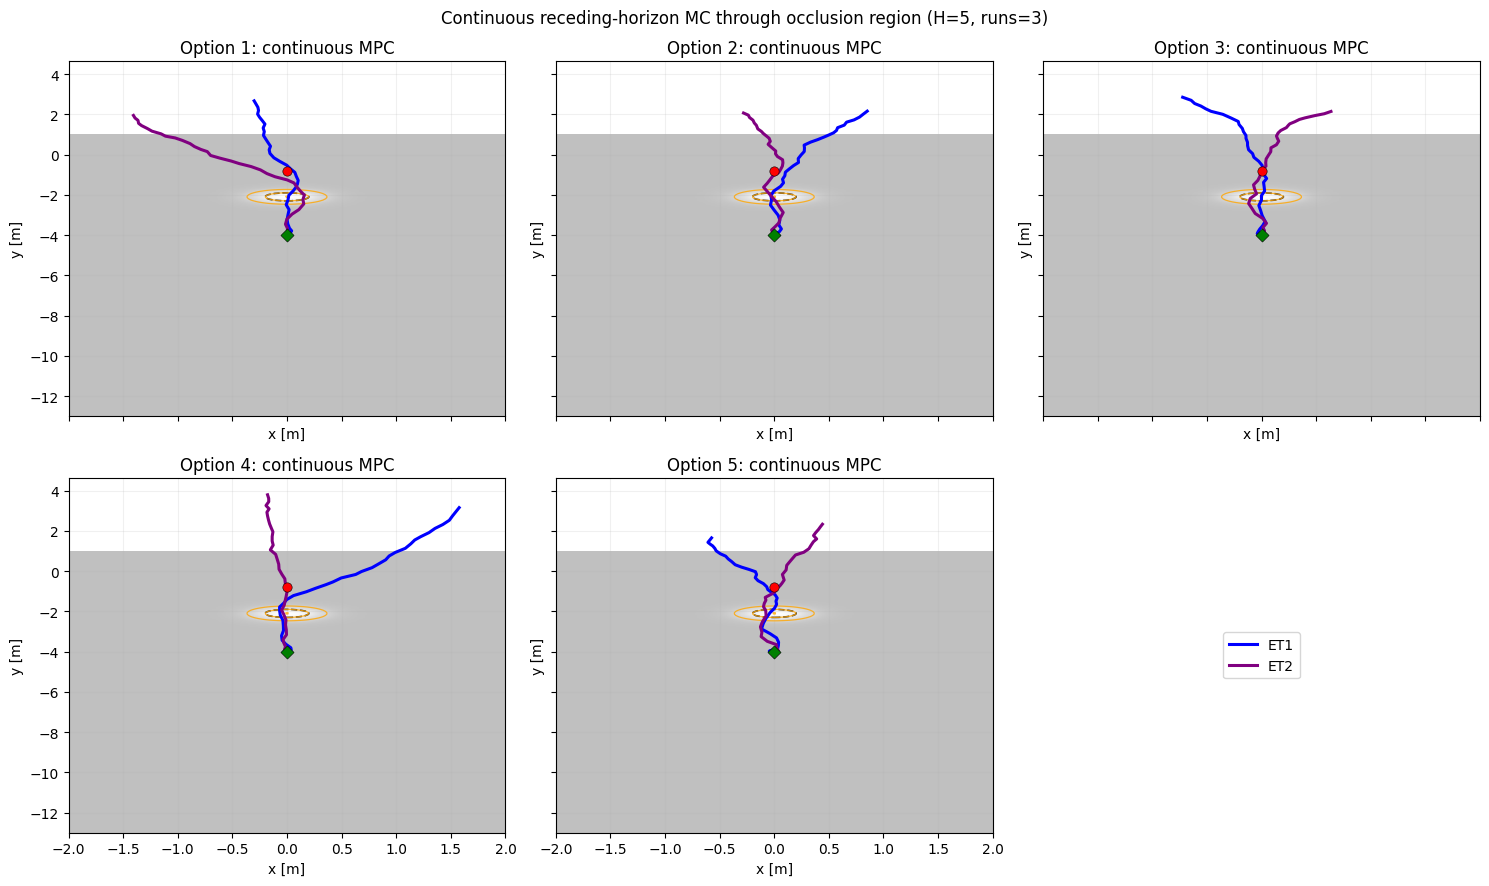

{'option': 1, 'method': 'ET1', 'success_rate': 0.0, 'final_dist_mean': 3.5963655169751747, 'path_len_mean': 7.05504573256632, 'control_effort_mean': 22.01745630604105, 'mean_p_vis': 0.9425472476749935, 'low_vis_frac': 0.041666666666666664, 'corridor_violation_frac': 0.25833333333333336}
{'option': 1, 'method': 'ET2', 'success_rate': 0.0, 'final_dist_mean': 3.1029529058319696, 'path_len_mean': 6.589248468022784, 'control_effort_mean': 21.105533816057573, 'mean_p_vis': 0.9439818348843514, 'low_vis_frac': 0.05, 'corridor_violation_frac': 0.45}
{'option': 2, 'method': 'ET1', 'success_rate': 0.0, 'final_dist_mean': 3.6018245635097643, 'path_len_mean': 6.995838273533551, 'control_effort_mean': 18.223578101526254, 'mean_p_vis': 0.9394237348762247, 'low_vis_frac': 0.041666666666666664, 'corridor_violation_frac': 0.48333333333333334}
{'option': 2, 'method': 'ET2', 'success_rate': 0.0, 'final_dist_mean': 3.462037191584892, 'path_len_mean': 6.965307826030852, 'control_effort_mean': 20.90653835200

In [ ]:
# Plot MC means + compact metrics table
try:
    import pandas as pd
except Exception:
    pd = None

xv = np.linspace(-2.0, 2.0, 220)
yv = np.linspace(-13.0, 1.0, 220)
XV, YV = np.meshgrid(xv, yv)
WV = p_vis_np(np.stack([XV, YV], axis=-1))

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
axes = axes.ravel()

rows = []

for i, opt in enumerate(options):
    ax = axes[i]
    ax.imshow(WV, extent=[xv.min(), xv.max(), yv.min(), yv.max()], origin='lower', cmap='Greys', alpha=0.25, aspect='auto')
    ax.contour(XV, YV, WV, levels=[0.2, 0.5, 0.8], colors='orange', linewidths=0.9, alpha=0.8)
    ax.add_patch(plt.Circle(occ_center, occ_radius, fill=False, ls='--', lw=1.2, color='k', alpha=0.8))

    for meth, color in [('ET1', 'blue'), ('ET2', 'purple')]:
        tr = results_mpc[(meth, opt)]['traj']
        mean_xy = tr[:, :, :2].mean(axis=0)
        ax.plot(mean_xy[:, 0], mean_xy[:, 1], color=color, lw=2.2, label=meth)

        final_dist = np.linalg.norm(tr[:, -1, :2] - goal_state[:2], axis=1)
        success = (final_dist < success_thr).mean()
        plen = np.mean([path_length(t[:, :2]) for t in tr])
        ueff = np.mean(np.sum(np.sum(results_mpc[(meth, opt)]['u']**2, axis=2), axis=1))
        mean_p = results_mpc[(meth, opt)]['p'].mean()
        low_vis = (results_mpc[(meth, opt)]['p'] < low_vis_thr).mean()
        corr_violation = np.mean(np.maximum(np.abs(tr[:, :, 0]) - corridor_half, 0.0) > 1e-6)

        rows.append({
            'option': opt,
            'method': meth,
            'success_rate': success,
            'final_dist_mean': float(np.mean(final_dist)),
            'path_len_mean': float(plen),
            'control_effort_mean': float(ueff),
            'mean_p_vis': float(mean_p),
            'low_vis_frac': float(low_vis),
            'corridor_violation_frac': float(corr_violation),
        })

    ax.scatter([start_state[0]], [start_state[1]], color='green', marker='D', s=45, edgecolors='black', linewidths=0.4, zorder=5)
    ax.scatter([goal_state[0]], [goal_state[1]], color='red', s=45, edgecolors='black', linewidths=0.4, zorder=5)
    ax.set_title(f'Option {opt}: continuous MPC')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.grid(alpha=0.18)

axes[-1].axis('off')
h, l = axes[0].get_legend_handles_labels()
axes[-1].legend(h, l, loc='center', frameon=True)

fig.suptitle(f'Continuous receding-horizon MC through occlusion region (H={len_horizon}, runs={n_runs_mc})', y=0.98)
fig.tight_layout()
plt.show()

if pd is not None:
    df = pd.DataFrame(rows).sort_values(['option', 'method']).round(4)
    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df.to_string(index=False))
else:
    for row in rows:
        print(row)


In [ ]:
# GP training data: balanced synthetic visibility dataset
rng_gp = np.random.default_rng(0)

# Keep aligned with notebook occlusion geometry
occ_center = np.array([0.0, -2.1])
occ_radius = 0.8
tau1 = 0.15

def p_true(xy):
    """High visibility outside occluder, low inside."""
    arr = np.asarray(xy, dtype=float)
    d = np.linalg.norm(arr - occ_center, axis=-1) - occ_radius
    return np.clip(1.0 / (1.0 + np.exp(-d / tau1)), 1e-4, 1.0 - 1e-4)

N_uniform, N_focus, N_inside = 320, 260, 220

X_uniform = np.column_stack([
    rng_gp.uniform(xmin, xmax, N_uniform),
    rng_gp.uniform(ymin, ymax, N_uniform),
])

X_focus = occ_center + rng_gp.normal(scale=[0.9, 0.9], size=(N_focus, 2))
X_focus[:, 0] = np.clip(X_focus[:, 0], xmin, xmax)
X_focus[:, 1] = np.clip(X_focus[:, 1], ymin, ymax)

ang = rng_gp.uniform(0.0, 2.0 * np.pi, N_inside)
rad = occ_radius * np.sqrt(rng_gp.uniform(0.0, 1.0, N_inside)) * 0.98
X_inside = np.column_stack([
    occ_center[0] + rad * np.cos(ang),
    occ_center[1] + rad * np.sin(ang),
])

X_train = np.vstack([X_uniform, X_focus, X_inside])
p_train = p_true(X_train)
y_train = (rng_gp.random(X_train.shape[0]) < p_train).astype(float)

print('N_train:', X_train.shape[0])
print('label mean:', float(y_train.mean()))
print('p_true range:', float(p_train.min()), float(p_train.max()))


In [ ]:
# Lightweight RBF GP (pure NumPy; avoids sklearn/scipy version issues)
class SimpleRBFGP:
    def __init__(self, length_scale=1.4, signal_var=1.0, noise_var=5e-2, jitter=1e-8):
        self.length_scale = float(length_scale)
        self.signal_var = float(signal_var)
        self.noise_var = float(noise_var)
        self.jitter = float(jitter)
        self.X_train = None
        self.y_mean = None
        self.L = None
        self.alpha = None

    def _kernel(self, Xa, Xb):
        Xa = np.asarray(Xa, dtype=float)
        Xb = np.asarray(Xb, dtype=float)
        d2 = np.sum((Xa[:, None, :] - Xb[None, :, :]) ** 2, axis=2)
        ls2 = max(self.length_scale ** 2, 1e-12)
        return self.signal_var * np.exp(-0.5 * d2 / ls2)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)
        self.X_train = X
        self.y_mean = float(y.mean())
        y0 = y - self.y_mean
        K = self._kernel(X, X) + (self.noise_var + self.jitter) * np.eye(X.shape[0])
        self.L = np.linalg.cholesky(K)
        self.alpha = np.linalg.solve(self.L.T, np.linalg.solve(self.L, y0))
        return self

    def predict(self, X, return_std=False):
        X = np.asarray(X, dtype=float)
        Ks = self._kernel(X, self.X_train)
        mu = self.y_mean + Ks @ self.alpha
        if not return_std:
            return mu
        v = np.linalg.solve(self.L, Ks.T)
        var = np.maximum(self.signal_var - np.sum(v * v, axis=0), 1e-12)
        return mu, np.sqrt(var)

gp_vis = SimpleRBFGP(length_scale=1.4, signal_var=1.0, noise_var=0.05).fit(X_train, y_train)
print('SimpleRBFGP fitted: ls=1.4, noise=0.05')


/home/joostleliveld/UnembodiedNavigation/.venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/joostleliveld/UnembodiedNavigation/.venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=[1, 1]) + WhiteKernel(noise_level=0.01),
                         normalize_y=True, random_state=0)

In [ ]:
from botnav_efe_helpers import sigma_points, ut_weights

def expected_p_vis(m, S):
    sp = sigma_points(m[:2], S[:2, :2], alpha=0.2)
    Wm, _ = ut_weights(2, alpha=0.2)
    mu, std = gp_vis.predict(sp, return_std=True)
    p = np.clip(mu, 1e-4, 1.0 - 1e-4)
    return float(Wm @ p), float(Wm @ (std ** 2))


In [ ]:
# GP visibility bridge for existing notebook pipeline

XY = np.stack([X.ravel(), Y.ravel()], axis=1)
P_mu, P_std = gp_vis.predict(XY, return_std=True)
P_all_gp = np.clip(P_mu.reshape(X.shape), 1e-4, 1.0 - 1e-4)
P_std_gp = P_std.reshape(X.shape)

# keep names used elsewhere
P_all = P_all_gp
vf = globals().get('valid_flat', None)
P_valid = P_all.ravel()[vf] if vf is not None else P_all.ravel()

print('GP map std:', float(np.std(P_all_gp)))
print('GP map percentiles:', np.percentile(P_all_gp, [0, 5, 25, 50, 75, 95, 100]))

def _bilinear_np(x, y, xs, ys, grid):
    ix = np.clip(np.searchsorted(xs, x, side='right') - 1, 0, len(xs) - 2)
    iy = np.clip(np.searchsorted(ys, y, side='right') - 1, 0, len(ys) - 2)
    x0, x1 = xs[ix], xs[ix + 1]
    y0, y1 = ys[iy], ys[iy + 1]
    tx = 0.0 if x1 == x0 else (x - x0) / (x1 - x0)
    ty = 0.0 if y1 == y0 else (y - y0) / (y1 - y0)
    z00 = grid[iy, ix]
    z10 = grid[iy, ix + 1]
    z01 = grid[iy + 1, ix]
    z11 = grid[iy + 1, ix + 1]
    return (1 - tx) * (1 - ty) * z00 + tx * (1 - ty) * z10 + (1 - tx) * ty * z01 + tx * ty * z11

def p_vis_np_state(m):
    p = _bilinear_np(float(m[0]), float(m[1]), xs, ys, P_all_gp)
    return float(np.clip(p, 1e-4, 1.0 - 1e-4))

def p_vis_np(xy, tau=None, eps=1e-4):
    arr = np.asarray(xy, dtype=float)
    flat = arr.reshape(-1, 2)
    out = np.empty(flat.shape[0], dtype=float)
    for i, (x, y) in enumerate(flat):
        out[i] = _bilinear_np(x, y, xs, ys, P_all_gp)
    out = np.clip(out, eps, 1.0 - eps)
    return out.reshape(arr.shape[:-1])

xs_j = jnp.asarray(xs)
ys_j = jnp.asarray(ys)
P_gp_j = jnp.asarray(P_all_gp)

def _bilinear_jax(x, y):
    ix = jnp.clip(jnp.searchsorted(xs_j, x, side='right') - 1, 0, xs_j.shape[0] - 2)
    iy = jnp.clip(jnp.searchsorted(ys_j, y, side='right') - 1, 0, ys_j.shape[0] - 2)

    x0, x1 = xs_j[ix], xs_j[ix + 1]
    y0, y1 = ys_j[iy], ys_j[iy + 1]
    tx = jnp.where(x1 == x0, 0.0, (x - x0) / (x1 - x0))
    ty = jnp.where(y1 == y0, 0.0, (y - y0) / (y1 - y0))

    z00 = P_gp_j[iy, ix]
    z10 = P_gp_j[iy, ix + 1]
    z01 = P_gp_j[iy + 1, ix]
    z11 = P_gp_j[iy + 1, ix + 1]

    return (1 - tx) * (1 - ty) * z00 + tx * (1 - ty) * z10 + (1 - tx) * ty * z01 + tx * ty * z11

def p_vis_j(m):
    return jnp.clip(_bilinear_jax(m[0], m[1]), 1e-4, 1.0 - 1e-4)

print('GP visibility bridge active.')


GP visibility bridge active.


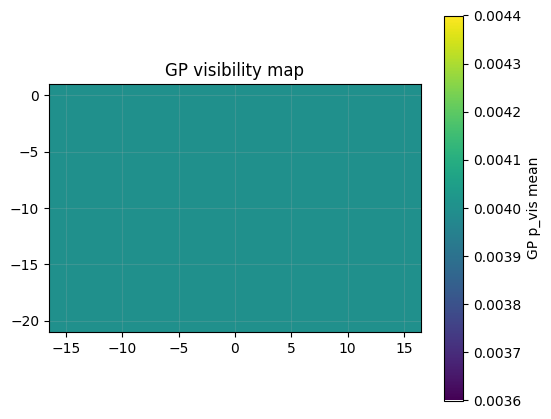

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(P_all_gp, extent=[xmin,xmax,ymin,ymax], origin='lower', cmap='viridis', aspect='equal')
plt.colorbar(label='GP p_vis mean')
plt.title('GP visibility map')
plt.show()
